# GAN Lab: Recovering from Mode Collapse

## Scenario

A GAN trained on MNIST produces recognizable images but generates only a limited set of digits and repeated visual patterns. The objective is to select a diversity-regularization strength that improves mode coverage without seriously reducing image quality.

The generator objective during recovery is

$$
\mathcal{L}_G=\mathcal{L}_{\mathrm{adversarial}}+\lambda_{\mathrm{div}}\mathcal{L}_{\mathrm{diversity}},
$$

where

$$
\mathcal{L}_{\mathrm{diversity}}
=-\mathbb{E}\left[
\frac{\lVert G(\mathbf z_1)-G(\mathbf z_2)\rVert_1}
{\lVert\mathbf z_1-\mathbf z_2\rVert_1+\epsilon}
\right].
$$

Compare

$$
\lambda_{\mathrm{div}}\in\{0,0.1,0.5,1.0\}.
$$

All recovery experiments begin from the same controlled mode-collapsed checkpoint.

## Required analysis

The final recommendation must use both quantitative and qualitative evidence. High numerical diversity is not sufficient: a generator can increase pixel variation by adding noise or distortions.

## 1. Environment and configuration

Run the notebook from top to bottom. A GPU is recommended. MNIST is downloaded automatically on the first run.

In [ ]:
from pathlib import Path
import copy
import json
import math
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

SEED = 42
LATENT_DIM = 32
DIVERSITY_WEIGHTS = [0.0, 0.1, 0.5, 1.0]
BATCH_SIZE = 256
LEARNING_RATE = 2e-4
CLASSIFIER_EPOCHS = 10
PRETRAIN_EPOCHS = 16
COLLAPSE_EPOCHS = 8
RECOVERY_EPOCHS = 5
COLLAPSE_DIGITS = [1, 7]
MODE_FREQUENCY_THRESHOLD = 0.01
EVALUATION_SAMPLES = 2500
NUM_WORKERS = 2
DATA_ROOT = Path("data")
OUTPUT_DIR = Path("outputs/gan_mode_collapse")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__} | device={device}")

PyTorch 2.11.0+cu128 | device=cuda


In [ ]:
def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything()

classifier_transform = transforms.ToTensor()
gan_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

classifier_train_data = datasets.MNIST(DATA_ROOT, train=True, download=True, transform=classifier_transform)
classifier_test_data = datasets.MNIST(DATA_ROOT, train=False, download=True, transform=classifier_transform)
gan_train_data = datasets.MNIST(DATA_ROOT, train=True, download=True, transform=gan_transform)

loader_options = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": torch.cuda.is_available(),
}

def make_loader(dataset, shuffle, seed=SEED):
    return DataLoader(
        dataset, shuffle=shuffle,
        generator=torch.Generator().manual_seed(seed) if shuffle else None,
        **loader_options,
    )

classifier_train_loader = make_loader(classifier_train_data, True)
classifier_test_loader = make_loader(classifier_test_data, False)
print(f"Training images: {len(gan_train_data):,} | test images: {len(classifier_test_data):,}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 454kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.70MB/s]

Training images: 60,000 | test images: 10,000


## 2. Train the evaluation classifier

A small MNIST classifier estimates the generated class distribution and extracts features for diversity measurements. Its predictions are evaluation aids, not perfect ground truth for generated images.

In [ ]:
class MNISTClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(inplace=True),
        )
        self.classifier = nn.Linear(128, 10)

    def forward(self, x, return_features=False):
        features = self.features(x)
        logits = self.classifier(features)
        return (logits, features) if return_features else logits

def train_classifier_epoch(model, loader, optimizer):
    model.train()
    correct = total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = F.cross_entropy(logits, labels)
        loss.backward()
        optimizer.step()
        correct += (logits.argmax(1) == labels).sum().item()
        total += labels.numel()
    return correct / total

@torch.no_grad()
def classifier_accuracy(model, loader):
    model.eval()
    correct = total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        predictions = model(images).argmax(1)
        correct += (predictions == labels).sum().item()
        total += labels.numel()
    return correct / total

In [ ]:
seed_everything()
evaluation_classifier = MNISTClassifier().to(device)
classifier_optimizer = torch.optim.Adam(evaluation_classifier.parameters(), lr=1e-3)
for epoch in range(1, CLASSIFIER_EPOCHS + 1):
    train_accuracy = train_classifier_epoch(evaluation_classifier, classifier_train_loader, classifier_optimizer)
    test_accuracy = classifier_accuracy(evaluation_classifier, classifier_test_loader)
    print(f"Classifier epoch {epoch}/{CLASSIFIER_EPOCHS}: train={train_accuracy:.4f}, test={test_accuracy:.4f}")
torch.save(evaluation_classifier.state_dict(), OUTPUT_DIR / "evaluation_classifier.pt")

Classifier epoch 1/10: train=0.8926, test=0.9724
Classifier epoch 2/10: train=0.9760, test=0.9841
Classifier epoch 3/10: train=0.9835, test=0.9871
Classifier epoch 4/10: train=0.9873, test=0.9885
Classifier epoch 5/10: train=0.9899, test=0.9885
Classifier epoch 6/10: train=0.9916, test=0.9884
Classifier epoch 7/10: train=0.9927, test=0.9903
Classifier epoch 8/10: train=0.9939, test=0.9901
Classifier epoch 9/10: train=0.9953, test=0.9910
Classifier epoch 10/10: train=0.9953, test=0.9907


## 3. GAN architecture and losses

The generator uses the non-saturating adversarial loss. Real images and generator outputs use the range $[-1,1]$.

In [ ]:
class Generator(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.latent_dim = latent_dim
        self.project = nn.Sequential(
            nn.Linear(latent_dim, 128 * 7 * 7),
            nn.BatchNorm1d(128 * 7 * 7),
            nn.ReLU(inplace=True),
        )
        self.net = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 1, 4, 2, 1),
            nn.Tanh(),
        )

    def forward(self, z):
        features = self.project(z).view(-1, 128, 7, 7)
        return self.net(features)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 1),
        )

    def forward(self, images):
        return self.net(images)

def initialize_weights(module):
    if isinstance(module, (nn.Conv2d, nn.ConvTranspose2d, nn.Linear)):
        nn.init.normal_(module.weight, 0.0, 0.02)
        if module.bias is not None:
            nn.init.zeros_(module.bias)
    elif isinstance(module, (nn.BatchNorm1d, nn.BatchNorm2d)):
        nn.init.normal_(module.weight, 1.0, 0.02)
        nn.init.zeros_(module.bias)

def set_requires_grad(model, value):
    for parameter in model.parameters():
        parameter.requires_grad_(value)

In [ ]:
adversarial_criterion = nn.BCEWithLogitsLoss()

def diversity_loss(fake_1, fake_2, z_1, z_2, epsilon=1e-6):
    output_distance = (fake_1 - fake_2).abs().flatten(1).mean(dim=1)
    latent_distance = (z_1 - z_2).abs().flatten(1).mean(dim=1)
    return -(output_distance / (latent_distance + epsilon)).mean()

def train_gan_epoch(generator, discriminator, loader, optimizer_g, optimizer_d,
                    diversity_weight=0.0):
    generator.train(); discriminator.train()
    totals = {"generator": 0.0, "adversarial": 0.0, "diversity": 0.0, "discriminator": 0.0}
    examples = 0

    for real_images, _ in loader:
        real_images = real_images.to(device, non_blocking=True)
        batch_size = real_images.size(0)
        real_targets = torch.ones(batch_size, 1, device=device)
        fake_targets = torch.zeros(batch_size, 1, device=device)
        z_1 = torch.randn(batch_size, LATENT_DIM, device=device)
        z_2 = torch.randn(batch_size, LATENT_DIM, device=device)
        fake_1 = generator(z_1)
        fake_2 = generator(z_2)

        set_requires_grad(discriminator, True)
        discriminator.train()
        optimizer_d.zero_grad(set_to_none=True)
        real_logits = discriminator(real_images)
        fake_logits_1 = discriminator(fake_1.detach())
        fake_logits_2 = discriminator(fake_2.detach())
        loss_d = adversarial_criterion(real_logits, real_targets)
        loss_d += 0.5 * (
            adversarial_criterion(fake_logits_1, fake_targets)
            + adversarial_criterion(fake_logits_2, fake_targets)
        )
        loss_d.backward()
        optimizer_d.step()

        set_requires_grad(discriminator, False)
        discriminator.eval()
        optimizer_g.zero_grad(set_to_none=True)
        adversarial = 0.5 * (
            adversarial_criterion(discriminator(fake_1), real_targets)
            + adversarial_criterion(discriminator(fake_2), real_targets)
        )
        diversity = diversity_loss(fake_1, fake_2, z_1, z_2)
        loss_g = adversarial + diversity_weight * diversity
        loss_g.backward()
        optimizer_g.step()
        set_requires_grad(discriminator, True)

        totals["generator"] += loss_g.item() * batch_size
        totals["adversarial"] += adversarial.item() * batch_size
        totals["diversity"] += diversity.item() * batch_size
        totals["discriminator"] += loss_d.item() * batch_size
        examples += batch_size

    return {key: value / examples for key, value in totals.items()}

## 4. Create a common mode-collapsed checkpoint

The GAN first learns the complete MNIST distribution using the standard adversarial objective. It then continues adversarial training with real data restricted to digits 1 and 7. The discriminator still rewards realistic handwritten digits, but the biased target distribution encourages the generator to discard the other class modes. This produces a recognizable, class-collapsed checkpoint from which all recovery experiments begin.

In [ ]:
seed_everything()
base_generator = Generator().to(device).apply(initialize_weights)
base_discriminator = Discriminator().to(device).apply(initialize_weights)
base_optimizer_g = torch.optim.Adam(base_generator.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))
base_optimizer_d = torch.optim.Adam(base_discriminator.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))
base_loader = make_loader(gan_train_data, True, SEED)

for epoch in range(1, PRETRAIN_EPOCHS + 1):
    metrics = train_gan_epoch(
        base_generator, base_discriminator, base_loader,
        base_optimizer_g, base_optimizer_d,
    )
    print(f"Pretraining {epoch}/{PRETRAIN_EPOCHS}: G={metrics['generator']:.3f}, D={metrics['discriminator']:.3f}")

collapse_indices = [
    index for index, label in enumerate(gan_train_data.targets.tolist())
    if label in COLLAPSE_DIGITS
]
collapse_data = Subset(gan_train_data, collapse_indices)
collapse_loader = make_loader(collapse_data, True, SEED + 1)
print(
    f"Controlled collapse uses {len(collapse_data):,} real examples "
    f"from digits {COLLAPSE_DIGITS}."
)

for epoch in range(1, COLLAPSE_EPOCHS + 1):
    metrics = train_gan_epoch(
        base_generator, base_discriminator, collapse_loader,
        base_optimizer_g, base_optimizer_d,
    )
    print(
        f"Biased-data phase {epoch}/{COLLAPSE_EPOCHS}: "
        f"G={metrics['generator']:.3f}, D={metrics['discriminator']:.3f}"
    )

collapsed_generator_state = copy.deepcopy(base_generator.state_dict())
collapsed_discriminator_state = copy.deepcopy(base_discriminator.state_dict())
collapsed_optimizer_g_state = copy.deepcopy(base_optimizer_g.state_dict())
collapsed_optimizer_d_state = copy.deepcopy(base_optimizer_d.state_dict())
torch.save(collapsed_generator_state, OUTPUT_DIR / "collapsed_generator.pt")
torch.save(collapsed_discriminator_state, OUTPUT_DIR / "collapsed_discriminator.pt")

Pretraining 1/16: G=1.536, D=0.443
Pretraining 2/16: G=1.380, D=0.554
Pretraining 3/16: G=1.482, D=0.168
Pretraining 4/16: G=2.813, D=0.011
Pretraining 5/16: G=3.071, D=0.001
Pretraining 6/16: G=3.145, D=0.001
Pretraining 7/16: G=3.281, D=0.000
Pretraining 8/16: G=3.421, D=0.000
Pretraining 9/16: G=3.463, D=0.000
Pretraining 10/16: G=3.470, D=0.000
Pretraining 11/16: G=3.391, D=0.000
Pretraining 12/16: G=3.380, D=0.000
Pretraining 13/16: G=3.508, D=0.000
Pretraining 14/16: G=3.608, D=0.000
Pretraining 15/16: G=3.779, D=0.000
Pretraining 16/16: G=3.825, D=0.000
Controlled collapse uses 13,007 real examples from digits [1, 7].
Biased-data phase 1/8: G=2.851, D=0.000
Biased-data phase 2/8: G=2.932, D=0.000
Biased-data phase 3/8: G=3.086, D=0.000
Biased-data phase 4/8: G=3.194, D=0.000
Biased-data phase 5/8: G=3.306, D=0.000
Biased-data phase 6/8: G=3.385, D=0.000
Biased-data phase 7/8: G=3.451, D=0.000
Biased-data phase 8/8: G=3.533, D=0.000


## 5. Evaluation functions

Generated images are assigned digit labels by the evaluation classifier. A class is counted as represented when at least 1% of generated samples are assigned to it. Normalized class entropy is

$$
H_{\mathrm{norm}}=-\frac{1}{\log 10}\sum_{c=0}^{9}\hat p(c)\log\hat p(c).
$$

Feature diversity is the average pairwise distance between classifier features. Within-class diversity is calculated separately inside each predicted class.

In [ ]:
@torch.no_grad()
def evaluate_generator(generator, classifier, sample_count=EVALUATION_SAMPLES, seed=SEED + 500):
    generator.eval(); classifier.eval()
    local_generator = torch.Generator(device=device).manual_seed(seed)
    image_batches, probability_batches, feature_batches = [], [], []

    for start in range(0, sample_count, BATCH_SIZE):
        current_batch = min(BATCH_SIZE, sample_count - start)
        z = torch.randn(current_batch, LATENT_DIM, generator=local_generator, device=device)
        generated = generator(z)
        classifier_images = (generated + 1) / 2
        logits, features = classifier(classifier_images, return_features=True)
        image_batches.append(generated.cpu())
        probability_batches.append(torch.softmax(logits, dim=1).cpu())
        feature_batches.append(features.cpu())

    images = torch.cat(image_batches)
    probabilities = torch.cat(probability_batches)
    features = torch.cat(feature_batches)
    predictions = probabilities.argmax(dim=1)
    counts = torch.bincount(predictions, minlength=10)
    frequencies = counts.float() / sample_count
    entropy = -(frequencies * torch.log(frequencies.clamp_min(1e-12))).sum() / math.log(10)
    mode_count = int((frequencies >= MODE_FREQUENCY_THRESHOLD).sum().item())
    confidence = probabilities.max(dim=1).values.mean().item()

    diversity_subset = features[:1000]
    feature_diversity = torch.pdist(diversity_subset, p=2).mean().item()
    class_diversities = []
    for digit in range(10):
        class_features = features[predictions == digit][:200]
        if len(class_features) >= 2:
            class_diversities.append(torch.pdist(class_features, p=2).mean().item())
    within_class_diversity = float(np.mean(class_diversities)) if class_diversities else 0.0

    return {
        "images": images,
        "predictions": predictions,
        "class_frequencies": frequencies,
        "mode_count": mode_count,
        "normalized_entropy": entropy.item(),
        "classifier_confidence": confidence,
        "feature_diversity": feature_diversity,
        "within_class_diversity": within_class_diversity,
    }

def show_image_grid(images, title, rows=4, columns=16):
    fig, axes = plt.subplots(rows, columns, figsize=(14, 4))
    for axis, image in zip(axes.flat, images[:rows * columns]):
        axis.imshow(image.squeeze(), cmap="gray", vmin=-1, vmax=1)
        axis.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    return fig

Collapsed checkpoint | modes=1/10 | entropy=0.023 | confidence=0.969 | feature diversity=14.886 | mass on [1, 7]=0.000
Diagnostic: target modes are not yet dominant; increase COLLAPSE_EPOCHS and rerun.


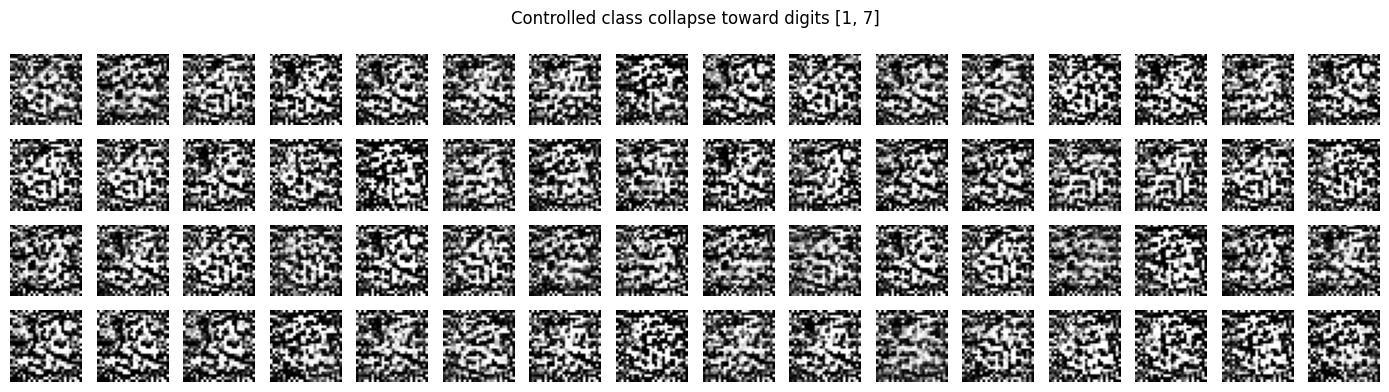

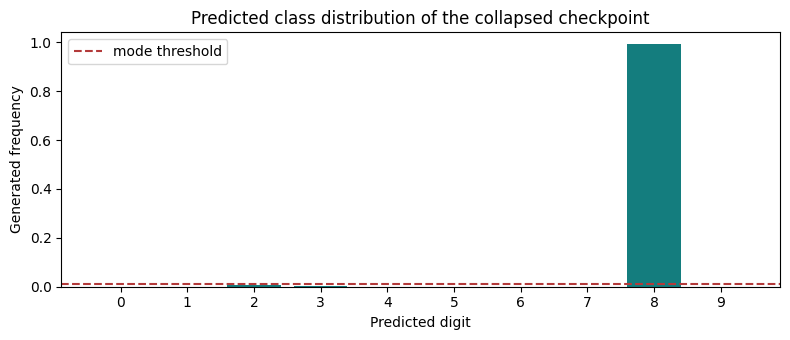

In [ ]:
collapsed_evaluation = evaluate_generator(base_generator, evaluation_classifier)
target_mode_mass = collapsed_evaluation["class_frequencies"][COLLAPSE_DIGITS].sum().item()
print(
    f"Collapsed checkpoint | modes={collapsed_evaluation['mode_count']}/10 | "
    f"entropy={collapsed_evaluation['normalized_entropy']:.3f} | "
    f"confidence={collapsed_evaluation['classifier_confidence']:.3f} | "
    f"feature diversity={collapsed_evaluation['feature_diversity']:.3f} | "
    f"mass on {COLLAPSE_DIGITS}={target_mode_mass:.3f}"
)
if target_mode_mass < 0.75:
    print("Diagnostic: target modes are not yet dominant; increase COLLAPSE_EPOCHS and rerun.")
if collapsed_evaluation['classifier_confidence'] < 0.75:
    print("Diagnostic: samples may be unclear; increase PRETRAIN_EPOCHS before extending collapse.")
fig = show_image_grid(
    collapsed_evaluation["images"],
    f"Controlled class collapse toward digits {COLLAPSE_DIGITS}",
)
plt.savefig(OUTPUT_DIR / "collapsed_samples.png", dpi=180, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 3.5))
plt.bar(range(10), collapsed_evaluation["class_frequencies"].numpy(), color="#147D7E")
plt.axhline(MODE_FREQUENCY_THRESHOLD, color="#B33A3A", linestyle="--", label="mode threshold")
plt.xticks(range(10)); plt.xlabel("Predicted digit"); plt.ylabel("Generated frequency")
plt.title("Predicted class distribution of the collapsed checkpoint")
plt.legend(); plt.tight_layout()
plt.savefig(OUTPUT_DIR / "collapsed_class_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

### Diagnosis checkpoint

1. What evidence indicates collapse between digit classes?
2. Do the samples also show repetition within represented classes?
3. Are individual images recognizable despite limited diversity?
4. Which diagnostic reveals information that GAN losses alone would not show?

## 6. Run the recovery experiments

Every candidate restores the same generator, discriminator, and optimizer states. The data order and random seed are also reset.

In [ ]:
recovered_generators = {}
recovery_histories = {}
evaluations = {"Collapsed start": collapsed_evaluation}
summary_rows = [{
    "Configuration": "Collapsed start",
    "Lambda diversity": np.nan,
    **{key: collapsed_evaluation[key] for key in [
        "mode_count", "normalized_entropy", "classifier_confidence",
        "feature_diversity", "within_class_diversity",
    ]},
}]

for diversity_weight in DIVERSITY_WEIGHTS:
    label = f"lambda={diversity_weight:g}"
    print(f"\n{'=' * 64}\nRecovery with {label}\n{'=' * 64}")
    seed_everything(SEED + 100)
    generator = Generator().to(device)
    discriminator = Discriminator().to(device)
    generator.load_state_dict(collapsed_generator_state)
    discriminator.load_state_dict(collapsed_discriminator_state)
    optimizer_g = torch.optim.Adam(generator.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))
    optimizer_d = torch.optim.Adam(discriminator.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))
    optimizer_g.load_state_dict(collapsed_optimizer_g_state)
    optimizer_d.load_state_dict(collapsed_optimizer_d_state)
    recovery_loader = make_loader(gan_train_data, True, SEED + 100)
    history = []
    started = time.time()

    for epoch in range(1, RECOVERY_EPOCHS + 1):
        metrics = train_gan_epoch(
            generator, discriminator, recovery_loader, optimizer_g, optimizer_d,
            diversity_weight=diversity_weight,
        )
        history.append({"epoch": epoch, **metrics})
        print(
            f"Epoch {epoch}/{RECOVERY_EPOCHS}: total G={metrics['generator']:.3f}, "
            f"adversarial={metrics['adversarial']:.3f}, D={metrics['discriminator']:.3f}"
        )

    evaluation = evaluate_generator(generator, evaluation_classifier)
    evaluations[label] = evaluation
    recovered_generators[diversity_weight] = generator
    recovery_histories[diversity_weight] = pd.DataFrame(history)
    summary_rows.append({
        "Configuration": label,
        "Lambda diversity": diversity_weight,
        **{key: evaluation[key] for key in [
            "mode_count", "normalized_entropy", "classifier_confidence",
            "feature_diversity", "within_class_diversity",
        ]},
        "Recovery seconds": time.time() - started,
    })
    torch.save(generator.state_dict(), OUTPUT_DIR / f"generator_lambda_{diversity_weight:g}.pt")

summary = pd.DataFrame(summary_rows)
summary


Recovery with lambda=0
Epoch 1/5: total G=4.299, adversarial=4.299, D=0.000
Epoch 2/5: total G=4.194, adversarial=4.194, D=0.000
Epoch 3/5: total G=4.321, adversarial=4.321, D=0.000
Epoch 4/5: total G=4.314, adversarial=4.314, D=0.000
Epoch 5/5: total G=4.338, adversarial=4.338, D=0.000

Recovery with lambda=0.1
Epoch 1/5: total G=4.248, adversarial=4.310, D=0.000
Epoch 2/5: total G=4.374, adversarial=4.436, D=0.000
Epoch 3/5: total G=4.540, adversarial=4.602, D=0.000
Epoch 4/5: total G=4.539, adversarial=4.601, D=0.000
Epoch 5/5: total G=4.547, adversarial=4.609, D=0.000

Recovery with lambda=0.5
Epoch 1/5: total G=4.106, adversarial=4.415, D=0.000
Epoch 2/5: total G=4.417, adversarial=4.729, D=0.000
Epoch 3/5: total G=4.571, adversarial=4.885, D=0.000
Epoch 4/5: total G=4.519, adversarial=4.834, D=0.000
Epoch 5/5: total G=4.425, adversarial=4.737, D=0.000

Recovery with lambda=1
Epoch 1/5: total G=3.973, adversarial=4.593, D=0.000
Epoch 2/5: total G=4.412, adversarial=5.045, D=0.000

,Configuration,Lambda diversity,mode_count,normalized_entropy,classifier_confidence,feature_diversity,within_class_diversity,Recovery seconds
0,Collapsed start,NaN,1,0.023493,0.968881,14.886327,11.351756,NaN
1,lambda=0,0.0,2,0.059538,0.950563,15.638906,10.087833,71.341263
2,lambda=0.1,0.1,2,0.047750,0.954109,15.393776,9.220779,72.157974
3,lambda=0.5,0.5,2,0.059987,0.943915,15.479863,11.321554,71.142371
4,lambda=1,1.0,4,0.164321,0.902365,17.067894,11.563861,71.035280


## 7. Compare sample quality and class coverage

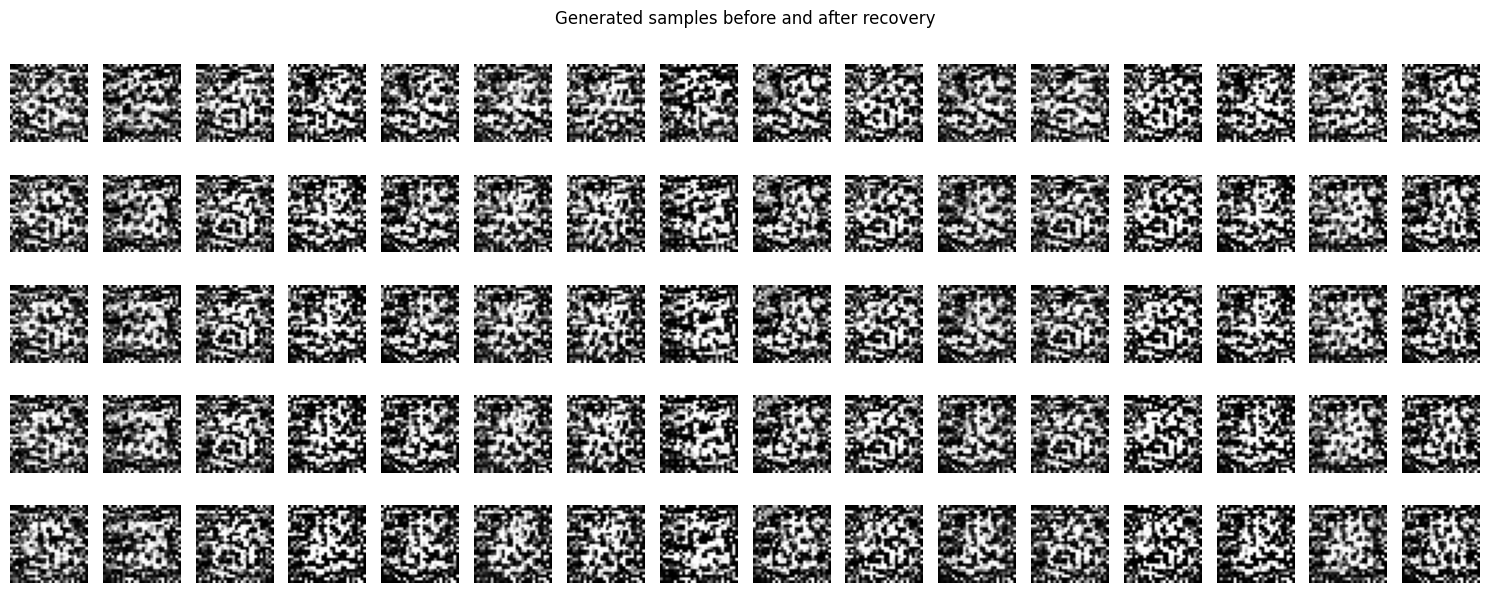

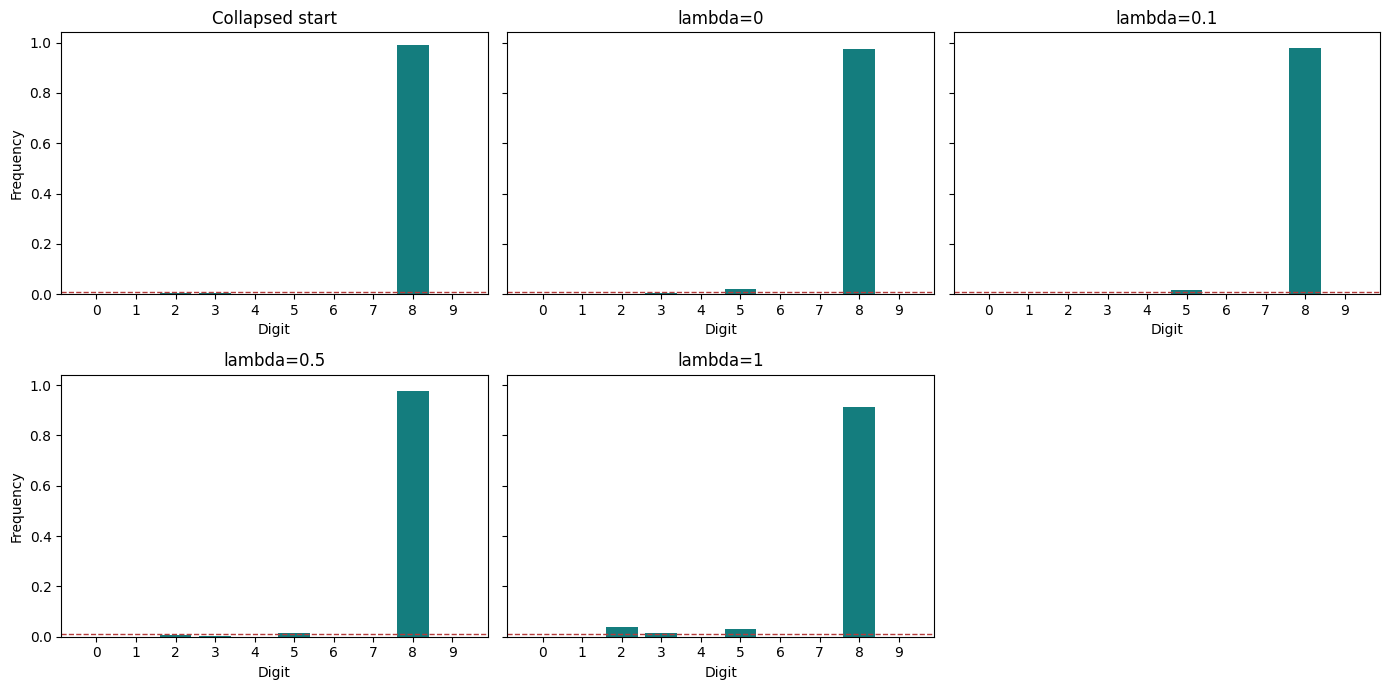

In [ ]:
comparison_labels = ["Collapsed start"] + [f"lambda={value:g}" for value in DIVERSITY_WEIGHTS]
fig, axes = plt.subplots(len(comparison_labels), 16, figsize=(15, 6.2))
for row_index, label in enumerate(comparison_labels):
    images = evaluations[label]["images"][:16]
    for column_index, image in enumerate(images):
        axes[row_index, column_index].imshow(image.squeeze(), cmap="gray", vmin=-1, vmax=1)
        axes[row_index, column_index].axis("off")
    axes[row_index, 0].set_ylabel(label, rotation=0, labelpad=55, va="center", fontsize=9)
plt.suptitle("Generated samples before and after recovery")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "recovery_samples.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=True)
for axis, label in zip(axes.flat, comparison_labels):
    frequencies = evaluations[label]["class_frequencies"].numpy()
    axis.bar(range(10), frequencies, color="#147D7E")
    axis.axhline(MODE_FREQUENCY_THRESHOLD, color="#B33A3A", linestyle="--", linewidth=1)
    axis.set_title(label); axis.set_xticks(range(10)); axis.set_xlabel("Digit")
axes[0, 0].set_ylabel("Frequency"); axes[1, 0].set_ylabel("Frequency")
axes.flat[-1].axis("off")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "class_distributions.png", dpi=180, bbox_inches="tight")
plt.show()

### Interpretation checkpoint

1. Which value recovers the largest number of digit classes?
2. Does class coverage improve together with visual realism?
3. Are samples meaningfully different or merely noisier?
4. Does any candidate remain repetitive within individual classes?

## 8. Compare quantitative metrics

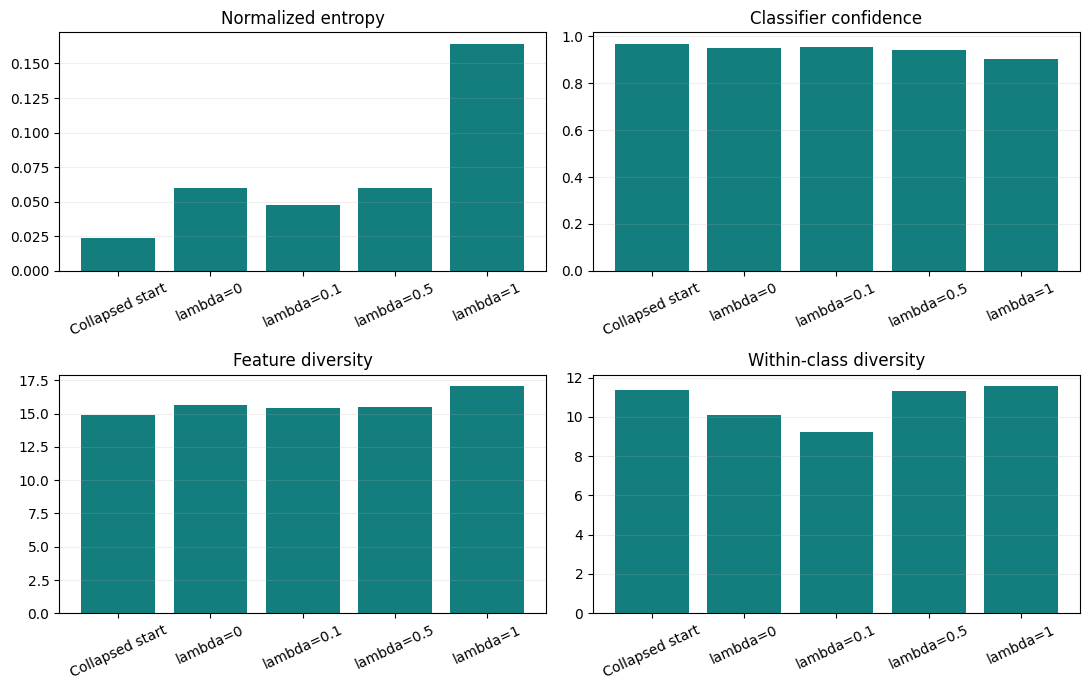

,Configuration,Lambda diversity,mode_count,normalized_entropy,classifier_confidence,feature_diversity,within_class_diversity,Recovery seconds
0,Collapsed start,NaN,1,0.023493,0.968881,14.886327,11.351756,NaN
1,lambda=0,0.0,2,0.059538,0.950563,15.638906,10.087833,71.341263
2,lambda=0.1,0.1,2,0.047750,0.954109,15.393776,9.220779,72.157974
3,lambda=0.5,0.5,2,0.059987,0.943915,15.479863,11.321554,71.142371
4,lambda=1,1.0,4,0.164321,0.902365,17.067894,11.563861,71.035280


In [ ]:
summary.to_csv(OUTPUT_DIR / "results.csv", index=False)
report_table = summary.drop(columns=["Recovery seconds"], errors="ignore").rename(columns={
    "Configuration": "Configuration",
    "Lambda diversity": r"$\lambda_{div}$",
    "mode_count": "Modes",
    "normalized_entropy": "Entropy",
    "classifier_confidence": "Confidence",
    "feature_diversity": "Feature diversity",
    "within_class_diversity": "Within-class diversity",
})
report_table.to_latex(
    OUTPUT_DIR / "summary_table.tex", index=False, escape=False,
    float_format=lambda value: f"{value:.3f}",
)

metric_columns = ["normalized_entropy", "classifier_confidence", "feature_diversity", "within_class_diversity"]
metric_titles = ["Normalized entropy", "Classifier confidence", "Feature diversity", "Within-class diversity"]
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for axis, column, title in zip(axes.flat, metric_columns, metric_titles):
    axis.bar(summary["Configuration"], summary[column], color="#147D7E")
    axis.set_title(title); axis.tick_params(axis="x", rotation=25); axis.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "recovery_metrics.png", dpi=180, bbox_inches="tight")
plt.show()
summary

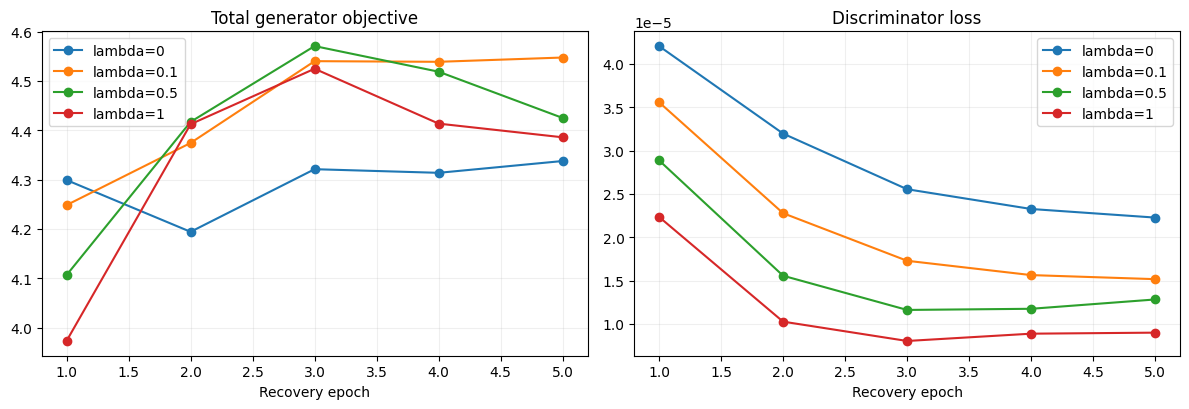

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for diversity_weight, history in recovery_histories.items():
    axes[0].plot(history["epoch"], history["generator"], marker="o", label=f"lambda={diversity_weight:g}")
    axes[1].plot(history["epoch"], history["discriminator"], marker="o", label=f"lambda={diversity_weight:g}")
axes[0].set_title("Total generator objective")
axes[1].set_title("Discriminator loss")
for axis in axes:
    axis.set_xlabel("Recovery epoch"); axis.grid(alpha=0.2); axis.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "recovery_training.png", dpi=180, bbox_inches="tight")
plt.show()

### Interpretation checkpoint

1. Do entropy and mode count agree with the class-distribution plots?
2. Does higher feature diversity always correspond to higher image quality?
3. Which candidate best improves within-class diversity?
4. Why should generator losses not be compared directly when $\lambda_{\mathrm{div}}$ changes?

In [ ]:
for diversity_weight, history in recovery_histories.items():
    history.to_csv(OUTPUT_DIR / f"history_lambda_{diversity_weight:g}.csv", index=False)
configuration = {
    "seed": SEED, "latent_dim": LATENT_DIM,
    "diversity_weights": DIVERSITY_WEIGHTS,
    "batch_size": BATCH_SIZE, "learning_rate": LEARNING_RATE,
    "classifier_epochs": CLASSIFIER_EPOCHS,
    "pretrain_epochs": PRETRAIN_EPOCHS,
    "collapse_epochs": COLLAPSE_EPOCHS,
    "recovery_epochs": RECOVERY_EPOCHS,
    "collapse_digits": COLLAPSE_DIGITS,
    "mode_frequency_threshold": MODE_FREQUENCY_THRESHOLD,
    "evaluation_samples": EVALUATION_SAMPLES,
    "device": str(device),
}
(OUTPUT_DIR / "configuration.json").write_text(json.dumps(configuration, indent=2))
print(f"All report files were saved in {OUTPUT_DIR.resolve()}")

All report files were saved in /content/outputs/gan_mode_collapse


In [ ]:
import shutil

# Comprime toda la carpeta 'outputs' en un archivo comprimido llamado 'resultados.zip'
shutil.make_archive('resultados', 'zip', 'outputs')

'/content/resultados.zip'

In [ ]:
from google.colab import files

files.download('resultados.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Final recommendation

Complete the accompanying report and recommend one value of $\lambda_{\mathrm{div}}$. The recommendation must reference:

- recovered mode count and class entropy;
- classifier confidence;
- feature and within-class diversity;
- visual sample quality; and
- at least one limitation of the selected configuration.

## Generated files

The folder `outputs/gan_mode_collapse/` contains the results table, histories, configuration, model checkpoints, and all figures required by the report.